In [80]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [81]:
import random
import matplotlib.pyplot as plt
import numpy as np
import scipy
from src.controllers.pid import PIDController
from src.config.models.dual_rotor_beam_drone import DualRotorBeamDroneModel, DualRotorBeamDroneConfig

In [82]:
drone_config = DualRotorBeamDroneConfig(
    length=0.3,
    mass=0.5,
    motor_base_thrust=5.0,
    max_thrust=15.0,
    min_thrust=0.0,
    gravity=9.81,
    angular_damping=0.0
)
drone = DualRotorBeamDroneModel(config=drone_config)


In [101]:
target_angle_history = []
current_angle_history = []
time_history = []
target = 0.0
current_angle = -25.0
angular_velocity = 0.0

time = 10.0
dt = 0.01
total_steps = int(time / dt)

kp = 0.15
ki = 0.0
kd = 0.0
pid = PIDController(kp=kp, ki=ki, kd=kd, dt=dt, max_integral_error=10.0)
pid.reset()

for step in range(total_steps):
    current_time = step * dt

    current_angle = drone.get_current_angle(current_angle)

    pid_output = pid.compute(target, current_angle)

    next_angle, next_angular_velocity, angular_acc, control = drone.step(
        angle=current_angle,
        angular_velocity=angular_velocity,
        pid_output=pid_output,
        dt=dt
    )

    angular_velocity = next_angular_velocity
    current_angle = next_angle

    target_angle_history.append(target)
    current_angle_history.append(current_angle)
    time_history.append(current_time)

print(f"Final angle: {current_angle:.2f} degrees")

Final angle: 24.80 degrees


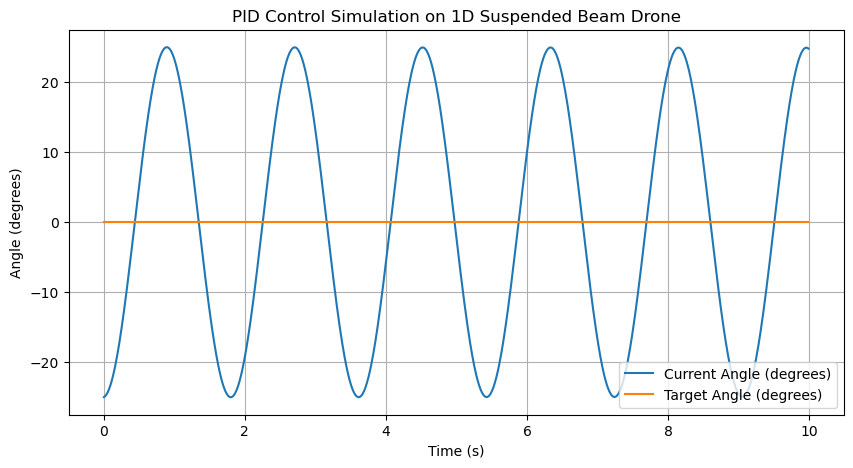

In [102]:
plt.figure(figsize=(10, 5))
plt.plot(time_history, current_angle_history, label='Current Angle (degrees)')
plt.plot(time_history, target_angle_history, label='Target Angle (degrees)')
plt.xlabel('Time (s)')
plt.ylabel('Angle (degrees)')
plt.title('PID Control Simulation on 1D Suspended Beam Drone')
plt.legend()
plt.grid(True)
plt.show()